# 04. Model Training

## Introduction

Model training is the process of teaching a machine learning algorithm to learn patterns and relationships from historical data. During this phase, the model uses the input features to understand how different factors influence the target variable.

In this project, multiple machine learning algorithms will be trained using the processed mental health dataset. The performance of these models will later be evaluated and compared to identify the most suitable model for depression risk prediction.

The trained model will serve as the foundation for prediction, explainability, and deployment in the later stages of the project.

---

## Objective

- Prepare the dataset for machine learning.
- Separate the features and target variable.
- Split the dataset into training and testing sets.
- Train multiple machine learning models.
- Save the trained models for further evaluation.

# 1. Features (X) and Target (y)

Machine learning models require the dataset to be divided into two components:

- **Features (X):** The input variables used by the model to learn patterns and relationships within the data.
- **Target (y):** The output variable that the model is trained to predict.

In this project, all processed columns except **Depression** are considered input features, while **Depression** serves as the target variable.

Separating the features and target variable ensures that the model learns from the input data without accessing the actual outcome during training, thereby preventing data leakage and enabling fair model evaluation.

---

## Objective

To separate the processed dataset into input features (`X`) and the target variable (`y`) for machine learning model training.

In [2]:
# Import required libraries
import pandas as pd

In [3]:
# Load the processed dataset
df = pd.read_csv("../Dataset/Processed/MindSense_AI_Cleaned_Dataset_v1.csv")

# Display first five rows
df.head()

,Gender,Age,Working Professional or Student,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,...,Degree_M.Tech,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_PhD
0,0,37,1,-1.0,2.0,-1.0,-1.0,4.0,2,1,...,0,1,0,0,0,0,0,0,0,0
1,1,60,1,-1.0,4.0,-1.0,-1.0,3.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,42,1,-1.0,2.0,-1.0,-1.0,3.0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,44,1,-1.0,3.0,-1.0,-1.0,5.0,2,2,...,0,0,0,0,0,1,0,0,0,0
4,1,48,1,-1.0,4.0,-1.0,-1.0,3.0,2,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Encode target variable
df["Depression"] = df["Depression"].map({
    "No": 0,
    "Yes": 1
})

In [5]:
# Separate input features
X = df.drop("Depression", axis=1)

# Separate target variable
y = df["Depression"]

In [6]:
# Display the shape of features and target
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2556, 107)
Shape of y: (2556,)


# 2. Train-Test Split

Machine learning models should be evaluated on data that was not used during training. Therefore, the dataset is divided into two subsets:

- **Training Set:** Used to train the machine learning model and learn patterns from the input data.
- **Testing Set:** Used to evaluate the model's performance on unseen data.

Separating the dataset into training and testing sets helps measure how well the model generalizes to new data and reduces the risk of overfitting.

---

## Objective

To split the dataset into training and testing subsets so that the machine learning model can be trained on one portion of the data and evaluated on unseen data.

## Why an 80:20 Train-Test Split?

An 80:20 train-test split is a commonly used approach in machine learning because it provides a good balance between model training and evaluation.

- **80% Training Data:** Allows the model to learn from a large number of samples and capture meaningful patterns.
- **20% Testing Data:** Provides sufficient unseen data to evaluate the model's performance and generalization ability.

Although 80:20 is a widely adopted practice, the split ratio may vary depending on the size of the dataset and the specific problem.

### Test Size (`test_size`)

The `test_size` parameter specifies the proportion of the dataset that should be reserved for testing the machine learning model.

For example:

- `test_size = 0.2` reserves **20%** of the dataset for testing and uses the remaining **80%** for training.
- `test_size = 0.3` reserves **30%** of the dataset for testing and uses **70%** for training.

Selecting an appropriate test size ensures that the model has sufficient data to learn meaningful patterns while retaining enough unseen data for reliable evaluation.

In this project, a **20% test size** is used because it provides a balanced split between training and testing data.

### Random State (`random_state`)

The `random_state` parameter controls the randomness of the train-test split.

By default, the dataset is randomly shuffled before splitting. As a result, running the same code multiple times may produce different training and testing datasets.

Setting a fixed value for `random_state` ensures that the same random split is generated every time the code is executed. This makes the experiment reproducible and allows consistent comparison of machine learning models.

In this project, `random_state=42` is used to ensure reproducible and consistent results.

### Stratified Sampling (`stratify`)

The `stratify` parameter ensures that the class distribution of the target variable is preserved in both the training and testing datasets.

For classification problems, the target variable may contain an unequal number of samples for each class. If the dataset is split randomly without stratification, the class proportions in the training and testing sets may differ from the original dataset, leading to biased model evaluation.

Using `stratify=y` maintains the same class distribution in both subsets, resulting in a more representative split and a more reliable evaluation of the machine learning model.

In this project, `stratify=y` is used to preserve the distribution of the **Depression** classes in both the training and testing datasets.

In [7]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (2044, 107)
X_test Shape  : (512, 107)
y_train Shape : (2044,)
y_test Shape  : (512,)


### Train-Test Split Output

The `train_test_split()` function returns four variables:

- **X_train:** Training features used to train the machine learning model.
- **X_test:** Testing features used to evaluate the trained model.
- **y_train:** Training target values corresponding to `X_train`.
- **y_test:** Testing target values corresponding to `X_test`.

During training, the model learns the relationship between `X_train` and `y_train`.

After training, the model makes predictions using `X_test`. These predictions are then compared with the actual target values (`y_test`) to evaluate the model's performance.

### Verify the Train-Test Split

After splitting the dataset, the shapes of the training and testing sets are displayed to verify that the split has been performed correctly.

- `X_train.shape` shows the number of training samples and features.
- `X_test.shape` shows the number of testing samples and features.
- `y_train.shape` shows the number of training target values.
- `y_test.shape` shows the number of testing target values.

Verifying the shapes helps ensure that:
- The dataset has been split according to the specified ratio.
- The number of feature columns remains unchanged.
- Each feature dataset has a corresponding target dataset.
- The data is ready for machine learning model training.

## 4.1 Logistic Regression

### Introduction

Logistic Regression is one of the most fundamental supervised machine learning algorithms used for **binary classification** problems.

Unlike linear regression, which predicts continuous numerical values, Logistic Regression predicts the **probability** that a data sample belongs to a particular class.

The predicted probability ranges from **0 to 1**. A threshold (commonly **0.5**) is then applied to convert the probability into one of the two class labels.

In this project, Logistic Regression is used to predict whether an individual is likely to experience **Depression (Yes/No)** based on the input features.

---

### Objective

To train a baseline Logistic Regression model for predicting depression and evaluate its performance on unseen data.

### The Sigmoid Function

The Sigmoid Function is the core mathematical function used in Logistic Regression.

Its purpose is to transform any real-valued input into a probability between **0 and 1**.

The output of the Sigmoid Function represents the probability that a data sample belongs to the positive class.

After computing this probability, a threshold (commonly **0.5**) is applied:

- If the probability is **greater than or equal to 0.5**, the sample is classified as the positive class.
- If the probability is **less than 0.5**, the sample is classified as the negative class.

The Sigmoid Function enables Logistic Regression to perform binary classification by converting continuous model outputs into probabilities.

### Weights in Logistic Regression

Weights represent the importance of each feature in making predictions.

Each feature has its own weight, and the model automatically learns these weights during training.

- A larger weight means the feature has a greater influence on the prediction.
- A smaller weight means the feature has less influence on the prediction.

The model learns the optimal weights from the training data to minimize prediction errors.

### Bias in Logistic Regression

Bias is an additional parameter added to the weighted sum of the input features.

It acts as an intercept, allowing the model to shift its predictions instead of always passing through zero.

Without the bias term, if all input features are zero, the model's output (`z`) will also be zero.

The bias provides flexibility and helps the model learn better decision boundaries from the training data.

The Logistic Regression equation is:

z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

where:

- `w` = Weights (importance of each feature)
- `x` = Input feature values
- `b` = Bias (intercept)

### Importing Logistic Regression

Scikit-learn is a popular Python library for Machine Learning.

The Logistic Regression algorithm is implemented inside the `linear_model` module of Scikit-learn.

Before using the algorithm, we must import it.

```python
from sklearn.linear_model import LogisticRegression
```

Here:

- `sklearn` → Scikit-learn library
- `linear_model` → Module containing linear algorithms
- `LogisticRegression` → Class used to create a Logistic Regression model

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

### Creating the Logistic Regression Model

After importing the `LogisticRegression` class, we create an instance of the model.

```python
model = LogisticRegression()
```

At this stage, the model is **not trained**.

It is simply an empty machine learning model with default parameters, ready to learn from the training data.

The actual learning happens when the `fit()` method is called.

### Training the Logistic Regression Model

The model is trained using the `fit()` method.

```python
model.fit(X_train, y_train)
```

Here:

- `X_train` contains the input features.
- `y_train` contains the corresponding target labels.

During training, the model learns the relationship between the input features and the target variable by finding the optimal weights and bias that minimize prediction errors.

This learning process is known as **Supervised Learning**, because the model learns using labeled data.

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

d:\MindSense-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Training the Model using `fit()`

The `fit()` method is responsible for training the Logistic Regression model.

```python
model.fit(X_train, y_train)
```

During training, the model:

1. Starts with initial weights and bias.
2. Uses the training features (`X_train`) to make predictions.
3. Compares the predictions with the actual target values (`y_train`).
4. Calculates the prediction error.
5. Adjusts the weights and bias to reduce the error.
6. Repeats the process until it finds the optimal parameters.

The learned weights and bias are then used to make predictions on new, unseen data.

In [10]:
y_pred = model.predict(X_test)

### Making Predictions

After training the model, predictions are made using the test features.

```python
y_pred = model.predict(X_test)
```

Only `X_test` is provided because the model must predict the target values on unseen data.

The true labels (`y_test`) are **not** passed during prediction.

Providing `y_test` during prediction would result in **data leakage**, leading to an unrealistic evaluation of the model's performance.

After predictions are generated, they are compared with `y_test` to evaluate the model.

### Model Evaluation

After generating predictions, the predicted values (`y_pred`) are compared with the actual target values (`y_test`).

This comparison helps evaluate how well the model performs on unseen data.

Common evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics help measure the model's prediction performance and identify its strengths and weaknesses.

### Model Evaluation

After generating predictions, the predicted values (`y_pred`) are compared with the actual target values (`y_test`).

This comparison helps evaluate how well the model performs on unseen data.

Common evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics help measure the model's prediction performance and identify its strengths and weaknesses.

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.98828125


### Limitations of Accuracy

Although accuracy is simple to understand, it is not always the best evaluation metric.

For imbalanced datasets, a model may achieve high accuracy by correctly predicting the majority class while failing to identify the minority class.

In medical and mental health prediction tasks, missing a patient who actually has the condition can have serious consequences.

Therefore, additional evaluation metrics such as **Confusion Matrix**, **Precision**, **Recall**, and **F1-Score** are essential for a more reliable assessment of model performance.

### Confusion Matrix

A Confusion Matrix is a table used to evaluate the performance of a classification model.

It categorizes predictions into four outcomes:

- **True Positive (TP):** The model correctly predicts the positive class.
- **True Negative (TN):** The model correctly predicts the negative class.
- **False Positive (FP):** The model incorrectly predicts the positive class.
- **False Negative (FN):** The model incorrectly predicts the negative class.

The Confusion Matrix provides more detailed insights into model performance than accuracy alone and forms the basis for calculating Precision, Recall, and F1-Score.

### Recall

Recall measures the model's ability to correctly identify all actual positive cases.

It answers the question:

**"Out of all the actual positive cases, how many did the model correctly detect?"**

Formula:

Recall = TP / (TP + FN)

Where:

- TP = True Positives
- FN = False Negatives

Recall is especially important in healthcare applications because missing a patient who actually has the disease can have serious consequences.

### Precision

Precision measures the proportion of predicted positive cases that are actually positive.

It answers the question:

**"Out of all the positive predictions made by the model, how many were correct?"**

Formula:

\[
\text{Precision}=\frac{TP}{TP+FP}
\]

Where:

- TP = True Positives
- FP = False Positives

A high Precision means that when the model predicts a positive case, it is usually correct.

Precision is important in applications where false alarms should be minimized.

### F1-Score

F1-Score is a performance metric that combines both Precision and Recall into a single value.

It is useful when both false positives and false negatives are important.

The F1-Score provides a balanced measure of a model's performance, especially for imbalanced datasets.

Formula:

\[
F1 = \frac{2 \times (\text{Precision} \times \text{Recall})}
{\text{Precision} + \text{Recall}}
\]

A high F1-Score indicates that the model has both high Precision and high Recall.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.98828125
Precision: 0.967032967032967
Recall   : 0.967032967032967
F1 Score : 0.967032967032967


### Logistic Regression Evaluation

The Logistic Regression model was evaluated using Accuracy, Precision, Recall, and F1-Score.

Results:

- Accuracy: **98.83%**
- Precision: **96.70%**
- Recall: **96.70%**
- F1-Score: **96.70%**

#### Interpretation

- The model correctly classified approximately **98.83%** of the test samples.
- A Precision of **96.70%** indicates that most positive predictions are correct.
- A Recall of **96.70%** indicates that the model successfully identifies most of the actual positive cases.
- The high F1-Score shows a good balance between Precision and Recall.

Overall, the Logistic Regression model demonstrates excellent performance for this dataset.

In [13]:
from sklearn.metrics import confusion_matrix

In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[418   3]
 [  3  88]]


### Confusion Matrix

The confusion matrix summarizes the performance of the Logistic Regression model.

|                | Predicted No | Predicted Yes |
|----------------|-------------:|--------------:|
| **Actual No**  | 418 | 3 |
| **Actual Yes** | 3 | 88 |

#### Interpretation

- **True Negatives (TN):** 418 healthy individuals were correctly classified as not having depression.
- **False Positives (FP):** 3 healthy individuals were incorrectly classified as having depression.
- **False Negatives (FN):** 3 individuals with depression were incorrectly classified as healthy.
- **True Positives (TP):** 88 individuals with depression were correctly identified.

The confusion matrix shows that the model makes very few classification errors, with only **6 incorrect predictions out of 512 test samples**, demonstrating excellent classification performance.

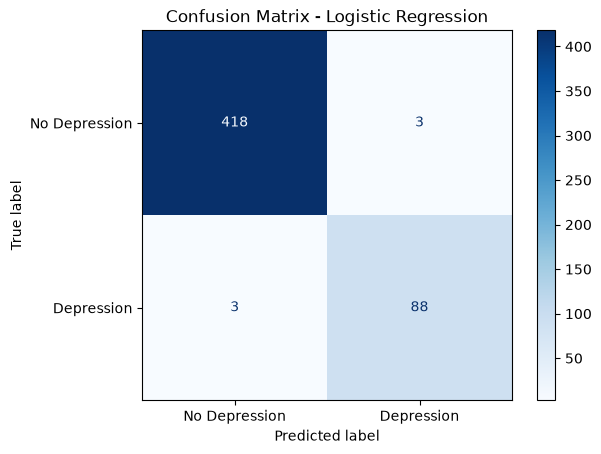

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Depression", "Depression"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Logistic Regression - Summary

The Logistic Regression model achieved excellent classification performance on the test dataset.

### Evaluation Results

- Accuracy: **98.83%**
- Precision: **96.70%**
- Recall: **96.70%**
- F1-Score: **96.70%**

### Confusion Matrix

|                | Predicted No | Predicted Yes |
|----------------|-------------:|--------------:|
| **Actual No**  | 418 | 3 |
| **Actual Yes** | 3 | 88 |

### Interpretation

- Correctly identified **418** non-depressed individuals.
- Correctly identified **88** depressed individuals.
- Misclassified only **6** out of **512** test samples.
- Only **3** depressed individuals were missed (False Negatives).
- Only **3** healthy individuals were incorrectly classified as depressed (False Positives).

Overall, the Logistic Regression model demonstrates excellent predictive performance and serves as a strong baseline for comparison with more advanced machine learning models.

### Decision Tree Terminology

A Decision Tree consists of three main components:

#### 1. Root Node

- The first node of the tree.
- Represents the initial decision based on the most informative feature.
- Every Decision Tree has only one root node.

#### 2. Decision Node

- An internal node that asks a question about a feature.
- Based on the answer, the data moves to the next branch.
- A tree can have multiple decision nodes.

#### 3. Leaf Node

- The final node of the tree.
- Represents the predicted class or output.
- Leaf nodes do not split further.

### How Does a Decision Tree Choose the Root Node?

A Decision Tree does not randomly select the root node.

Instead, it evaluates every feature and chooses the one that creates the best separation between the target classes.

The objective is to create the **purest possible groups** after each split.

For classification problems, the quality of a split is measured using criteria such as:

- **Gini Impurity** (default in scikit-learn)
- **Entropy (Information Gain)**

The feature that produces the purest child nodes becomes the root node.

### Gini Impurity

Gini Impurity measures how mixed the classes are within a node.

For binary classification:

\[
\text{Gini} = 1 - (P_{1}^{2} + P_{0}^{2})
\]

Where:

- \(P_1\) = Probability of class 1
- \(P_0\) = Probability of class 0

Interpretation:

- **Gini = 0** → Perfectly pure node (all samples belong to one class).
- **Higher Gini** → More mixed classes.
- A Decision Tree selects the split that results in the **lowest Gini Impurity**, producing the purest child nodes.

## Decision Tree Classifier

Scikit-learn provides the `DecisionTreeClassifier` class to build Decision Tree models for classification tasks.

The workflow is similar to Logistic Regression:

1. Import the classifier.
2. Create the model.
3. Train the model using `fit()`.
4. Make predictions using `predict()`.
5. Evaluate the model using metrics such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

This consistent API makes it easy to switch between different machine learning algorithms.

### max_depth in Decision Trees

The `max_depth` parameter controls the maximum number of levels that a Decision Tree can grow.

- A **small `max_depth`** creates a simpler tree that may miss some patterns (underfitting).
- A **large `max_depth`** creates a more complex tree that may memorize the training data (overfitting).

Choosing an appropriate `max_depth` helps the model generalize better to unseen data.

### Overfitting and max_depth

A Decision Tree with a very large `max_depth` can become too complex.

It keeps creating new splits until it memorizes the training data instead of learning general patterns.

This results in:

- Very high training accuracy.
- Lower performance on unseen (test) data.

This problem is known as **overfitting**.

The `max_depth` parameter helps control the complexity of the Decision Tree and improves its ability to generalize.

# Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks.

For classification, it recursively splits the dataset based on the feature that minimizes impurity (Gini Impurity by default in scikit-learn).

In this project, we will train a Decision Tree model to predict whether a student is likely to experience depression.

In [16]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Creating the Decision Tree Model

We create a Decision Tree classifier using the default parameters.

By default:
- Criterion = Gini Impurity
- Splitter = Best
- max_depth = None (tree grows until stopping conditions are met)

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)

## Training the Model

The `fit()` method trains the Decision Tree using the training dataset.

The model learns decision rules from the input features to predict the target variable.

In [18]:
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Making Predictions

After training, the Decision Tree predicts the target values for the test dataset using the learned decision rules.

In [19]:
y_pred_dt = dt_model.predict(X_test)

## Evaluating the Decision Tree

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

These metrics help assess the classification performance of the Decision Tree.

In [20]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Decision Tree Performance
------------------------------
Accuracy : 0.9258
Precision: 0.7789
Recall   : 0.8132
F1 Score : 0.7957


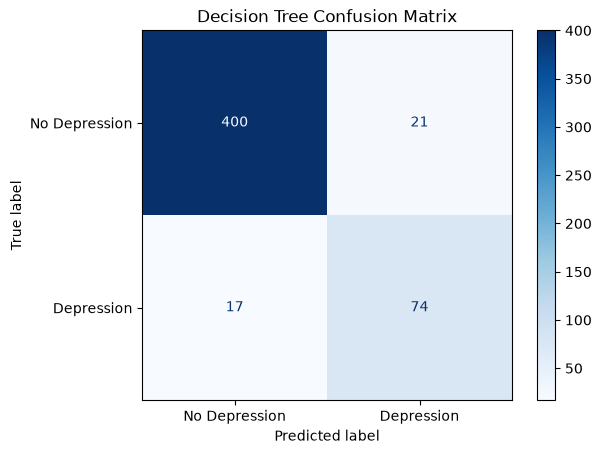

In [21]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Interpretation of the Decision Tree Results

The Decision Tree classifier achieved an accuracy of **92.58%**, indicating that it correctly classified most of the students in the test dataset.

From the confusion matrix:

- **True Negatives (TN): 400** students without depression were correctly classified.
- **True Positives (TP): 74** students with depression were correctly identified.
- **False Positives (FP): 21** students without depression were incorrectly predicted as having depression.
- **False Negatives (FN): 17** students with depression were incorrectly classified as not having depression.

The model achieved a **Precision of 77.89%**, meaning that approximately 78% of the students predicted as depressed were actually depressed.

The **Recall of 81.32%** indicates that the model successfully identified about 81% of the actual depression cases.

The **F1-Score of 79.57%** reflects a balanced performance between Precision and Recall.

Overall, the Decision Tree demonstrated good classification performance. However, compared with the Logistic Regression model, it produced lower Accuracy, Precision, Recall, and F1-Score, suggesting that Logistic Regression generalized better for this dataset.

# Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction performance.

Instead of relying on a single Decision Tree, Random Forest trains many Decision Trees on different subsets of the training data and combines their predictions.

For classification tasks, the final prediction is determined using **majority voting**.

Random Forest generally provides better accuracy, reduces overfitting, and improves generalization compared to a single Decision Tree.

## Bootstrap Sampling (Bagging)

Random Forest uses **Bootstrap Sampling**, also known as **Bagging (Bootstrap Aggregating)**.

Instead of training every Decision Tree on the entire dataset, each tree is trained on a different random sample of the original training data.

The samples are selected **with replacement**, meaning that:

- A sample may appear multiple times.
- Some samples may not appear in a particular training subset.

This introduces diversity among the Decision Trees, reducing overfitting and improving the model's ability to generalize.

## Working of Random Forest

Random Forest improves the performance of a single Decision Tree by introducing diversity among multiple trees.

The algorithm works in the following steps:

1. Create multiple bootstrap samples from the training dataset.
2. Train a separate Decision Tree on each bootstrap sample.
3. At every split, each tree considers only a random subset of the available features.
4. Each Decision Tree independently predicts the target class.
5. For classification, the final prediction is determined using **majority voting**.

This approach reduces overfitting, improves generalization, and usually achieves better predictive performance than a single Decision Tree.

# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction performance.

Unlike a single Decision Tree, Random Forest trains many Decision Trees using different bootstrap samples of the training data and random subsets of features.

For classification problems, the final prediction is determined using **majority voting**, where the class predicted by the majority of the trees becomes the final output.

Random Forest generally provides better accuracy, reduces overfitting, and improves generalization compared to a single Decision Tree.

In [22]:
from sklearn.ensemble import RandomForestClassifier

## Creating the Random Forest Model

A Random Forest classifier is created using the default parameters.

By default:

- Multiple Decision Trees are created.
- Bootstrap sampling is enabled.
- Random feature selection is used at each split.
- The final prediction is made using majority voting.

In [23]:
rf_model = RandomForestClassifier(random_state=42)

## Training the Model

The `fit()` method trains the Random Forest using the training dataset.

Each Decision Tree learns from a different bootstrap sample and random subset of features.

In [24]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Making Predictions

The trained Random Forest model predicts the target values for the test dataset using majority voting across all Decision Trees.

In [25]:
y_pred_rf = rf_model.predict(X_test)

## Model Evaluation

The Random Forest model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [26]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Performance
-----------------------------------
Accuracy : 0.9355
Precision: 0.9028
Recall   : 0.7143
F1 Score : 0.7975


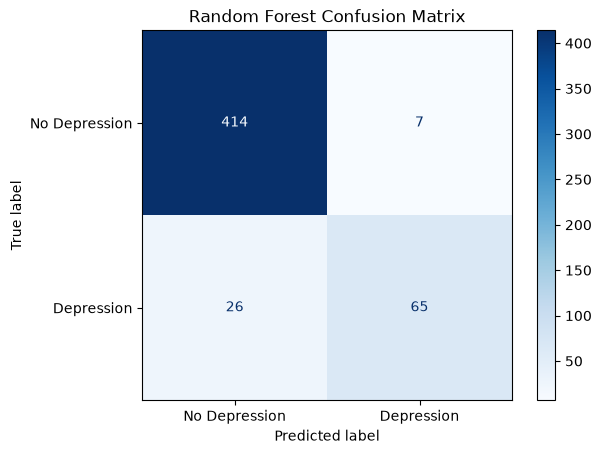

In [27]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Interpretation of the Random Forest Results

The Random Forest classifier achieved an accuracy of **93.55%**, correctly classifying most of the students in the test dataset.

From the confusion matrix:

- True Negatives (TN): 414
- True Positives (TP): 65
- False Positives (FP): 7
- False Negatives (FN): 26

The model achieved:

- Precision: **90.28%**
- Recall: **71.43%**
- F1-Score: **79.75%**

The Random Forest model produced very few false positives, resulting in high precision. However, it missed a larger number of actual depression cases, leading to a lower recall.

Compared with the Decision Tree, Random Forest improved Accuracy, Precision, and F1-Score. However, Logistic Regression remained the best-performing model, achieving higher Accuracy, Precision, Recall, and F1-Score on this dataset.